In [1]:
from langgraph.graph import START, END,StateGraph
from langchain_ollama import ChatOllama
from typing import TypedDict

In [2]:
class PostInput(TypedDict):
    topic: str 
    linkdin_post: str
    hashtags: str
    prompt_thumbnail: str

In [3]:
llm= ChatOllama(model="llama3.2:1b")

In [12]:
def post_creater(state:PostInput)->PostInput:
    topic=state["topic"]
    prompt=f"Write a post on the topic '{topic}' for linkdin in the way that i am sharing my personal experience and learning from it. The post should be in a way that it should be engaging and should have a hook in the starting. The post should be in a way that it should be shareable and should have a call to action at the end. The post not be more then 300 words"
    post=llm.invoke(prompt).content

    return {
        "linkdin_post": post}

In [13]:
def hashtags_creater(state:PostInput)->PostInput:
    topic=state["topic"]
    prompt=f"write 5 hashtags for the topic '{topic}' that are relevant and trending on linkdin. The hashtags should be in a way that it should be engaging the topic "
    hashtags=llm.invoke(prompt).content

    return {
        "hashtags": hashtags
    }

In [14]:
def thumbnail_prompt_creater(state:PostInput)->PostInput:
    topic=state["topic"]
    prompt=f"write a prompt for the topic '{topic}' that can be used to generate a thumbnail for the linkdin post. The prompt should be in a way that it it look real for this topic "
    prompt_thumbnail=llm.invoke(prompt).content

    return {
        
        "prompt_thumbnail": prompt_thumbnail
    }

In [15]:
graph=StateGraph(PostInput)

In [16]:
graph.add_node("post_creater", post_creater)
graph.add_node("hashtags_creater", hashtags_creater)
graph.add_node("thumbnail_prompt_creater", thumbnail_prompt_creater)
graph.add_edge(START, "post_creater")
graph.add_edge(START, "hashtags_creater")
graph.add_edge(START, "thumbnail_prompt_creater")
graph.add_edge("post_creater", END)
graph.add_edge("hashtags_creater", END)
graph.add_edge("thumbnail_prompt_creater", END)

In [17]:
app=graph.compile()

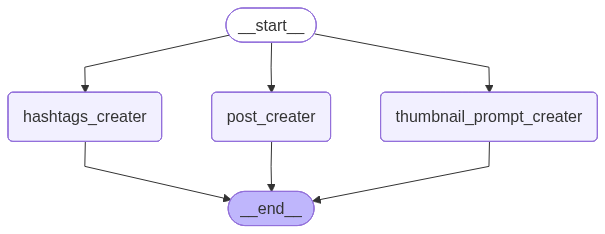

In [18]:
app

In [19]:
app.invoke({"topic": "AI in Healthcare"})

{'topic': 'AI in Healthcare',
 'linkdin_post': 'Here\'s a LinkedIn post on the topic \'AI in Healthcare\':\n\n**"The Future is Now: How AI is Revolutionizing Healthcare"**\n\nAs I reflect on my career journey, one of the most impactful experiences that has left an indelible mark is the transition from a small startup to a leading healthcare provider. What was once thought to be a niche market has now become a game-changer for our organization. But what drove this transformation? The answer lies in Artificial Intelligence (AI) – a technology that\'s been revolutionizing industries for decades, and I\'m excited to share my personal experience with you.\n\nFor those who may not know, AI refers to the use of computer systems based on algorithms and data to simulate human intelligence. In healthcare, AI is being used to analyze vast amounts of medical data, identify patterns, and make predictions that can improve patient outcomes. Our team has been at the forefront of this movement, leverag